# Color Quality Analysis for Temperature Determination

This notebook identifies which color values provide good agreement with Gaia T_eff measurements.

## Approach
- Use **relative residuals** based on Gaia T_eff: `|Gaia T_eff - Color T_eff| / Gaia T_eff`
- Test multiple thresholds: **3%, 5%, and 10%** (realistic for photometric temperatures)
- Create quality flags for each color-temperature relation
- Identify which colors are most reliable across the dataset

## Colors Analyzed
- **B-V** → Te_bv
- **V-K** → Te_vk  
- **g-r** → Te_gr
- **r-i** → Te_ri
- **i-z** → Te_iz


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set plotting style
plt.style.use('default')
sns.set_palette("husl")

# Set up paths
data_dir = Path('../data/processed')

# Load the Gaia catalog with proper motion
print("Loading Gaia catalog with proper motion...")
gaia_pm = pd.read_parquet(data_dir / 'eb_catalog_with_pm.parquet')
print(f"Gaia PM catalog shape: {gaia_pm.shape}")

# Load the Pan-STARRS photometry with all temperatures
print("Loading Pan-STARRS photometry with all temperatures...")
panstarrs_temp = pd.read_parquet(data_dir / 'gaia_eb_panstarrs_phot_with_temperatures.parquet')
print(f"Pan-STARRS temperature catalog shape: {panstarrs_temp.shape}")

# Join the tables
print("Joining tables on original_ext_source_id...")
merged = gaia_pm.merge(panstarrs_temp, on='original_ext_source_id', how='inner')
print(f"Merged catalog shape: {merged.shape}")

# Filter for valid Gaia temperatures
valid_gaia = merged['teff_gspphot'] > 0
print(f"\nObjects with valid Gaia T_eff: {valid_gaia.sum():,}")

# Calculate relative residuals for each color-temperature relation
print("\nCalculating relative residuals...")

# Te_bv (B-V)
merged['rel_resid_bv'] = np.abs(merged['teff_gspphot'] - merged['Te_bv']) / merged['teff_gspphot']

# Te_vk (V-K)
merged['rel_resid_vk'] = np.abs(merged['teff_gspphot'] - merged['Te_vk']) / merged['teff_gspphot']

# Te_gr (g-r)
merged['rel_resid_gr'] = np.abs(merged['teff_gspphot'] - merged['Te_gr']) / merged['teff_gspphot']

# Te_ri (r-i)
merged['rel_resid_ri'] = np.abs(merged['teff_gspphot'] - merged['Te_ri']) / merged['teff_gspphot']

# Te_iz (i-z)
merged['rel_resid_iz'] = np.abs(merged['teff_gspphot'] - merged['Te_iz']) / merged['teff_gspphot']

print("✓ Relative residuals calculated")
print(f"\nDataset now has {merged.shape[1]} columns")

merged.head()


Loading Gaia catalog with proper motion...
Gaia PM catalog shape: (1230649, 15)
Loading Pan-STARRS photometry with all temperatures...
Pan-STARRS temperature catalog shape: (1172535, 29)
Joining tables on original_ext_source_id...
Merged catalog shape: (1172580, 43)

Objects with valid Gaia T_eff: 720,005

Calculating relative residuals...
✓ Relative residuals calculated

Dataset now has 48 columns


,source_id,clean_panstarrs1_oid,original_ext_source_id,l,b,pmra,pmdec,pseudocolour,phot_g_mean_mag,phot_bp_mean_mag,...,B_V_color,R_I_color,V_K_color,Te_bv,Te_vk,rel_resid_bv,rel_resid_vk,rel_resid_gr,rel_resid_ri,rel_resid_iz
0,46626164993792,967166606,108690456271144410,176.988972,-48.049800,2.203996,-6.068640,NaN,19.931410,20.556221,...,0.616351,0.382500,1.601209,5929.171379,5684.134810,NaN,NaN,NaN,NaN,NaN
1,104487964717440,972259318,108950446169939982,175.688254,-48.616774,-1.782626,-18.938406,NaN,17.909193,19.156775,...,1.328427,1.204235,3.880688,4086.685886,3622.699565,0.128528,0.000399,0.114352,0.220906,0.045640
2,138577120584320,978183638,109270450082003814,175.823945,-48.154829,0.259084,-0.413995,NaN,15.532284,15.748469,...,0.549409,0.286599,1.365823,6165.716563,6048.632316,0.023979,0.042513,0.055687,0.073846,0.258283
3,160219460292352,973703324,109030455555466575,176.608400,-47.903013,2.130611,-6.538687,NaN,17.597319,18.101242,...,0.725370,0.544001,1.990567,5579.622054,5186.678760,0.213802,0.128320,0.171198,0.021844,0.121353
4,203551385701760,982701946,109510460340003115,176.680029,-47.283171,-21.000783,-43.917424,NaN,13.413368,14.149869,...,0.960968,0.372200,2.242953,4959.016580,4919.104854,0.191459,0.181869,0.144150,0.277712,0.105961


In [2]:
# Create quality flags for multiple thresholds
# Thresholds: 3%, 5%, and 10% relative difference

thresholds = [0.03, 0.05, 0.10]
color_names = ['bv', 'vk', 'gr', 'ri', 'iz']
color_labels = ['B-V', 'V-K', 'g-r', 'r-i', 'i-z']

print("Creating quality flags for each color at multiple thresholds...\n")

for threshold in thresholds:
    pct = int(threshold * 100)
    print(f"=== {pct}% Threshold ===")
    
    for color, label in zip(color_names, color_labels):
        # Create flag column
        flag_col = f'{color}_good_{pct}pct'
        merged[flag_col] = merged[f'rel_resid_{color}'] < threshold
        
        # Count valid measurements
        n_valid = merged[f'rel_resid_{color}'].notna().sum()
        n_good = merged[flag_col].sum()
        
        if n_valid > 0:
            pct_good = 100 * n_good / n_valid
            print(f"  {label:4s}: {n_good:7,} / {n_valid:7,} ({pct_good:5.2f}%) pass")
        else:
            print(f"  {label:4s}: No valid measurements")
    
    print()

print(f"✓ Quality flags created")
print(f"Dataset now has {merged.shape[1]} columns")

# Show example of flag columns
flag_columns = [col for col in merged.columns if '_good_' in col]
print(f"\nFlag columns created ({len(flag_columns)} total):")
for col in sorted(flag_columns):
    print(f"  - {col}")


Creating quality flags for each color at multiple thresholds...

=== 3% Threshold ===
  B-V :  87,763 / 712,811 (12.31%) pass
  V-K : 114,483 / 707,136 (16.19%) pass
  g-r : 106,264 / 720,005 (14.76%) pass
  r-i :  98,677 / 720,005 (13.71%) pass
  i-z :  88,813 / 720,005 (12.34%) pass

=== 5% Threshold ===
  B-V : 146,209 / 712,811 (20.51%) pass
  V-K : 194,815 / 707,136 (27.55%) pass
  g-r : 178,822 / 720,005 (24.84%) pass
  r-i : 160,412 / 720,005 (22.28%) pass
  i-z : 146,407 / 720,005 (20.33%) pass

=== 10% Threshold ===
  B-V : 295,864 / 712,811 (41.51%) pass
  V-K : 400,969 / 707,136 (56.70%) pass
  g-r : 361,545 / 720,005 (50.21%) pass
  r-i : 294,040 / 720,005 (40.84%) pass
  i-z : 276,580 / 720,005 (38.41%) pass

✓ Quality flags created
Dataset now has 63 columns

Flag columns created (15 total):
  - bv_good_10pct
  - bv_good_3pct
  - bv_good_5pct
  - gr_good_10pct
  - gr_good_3pct
  - gr_good_5pct
  - iz_good_10pct
  - iz_good_3pct
  - iz_good_5pct
  - ri_good_10pct
  - ri_go

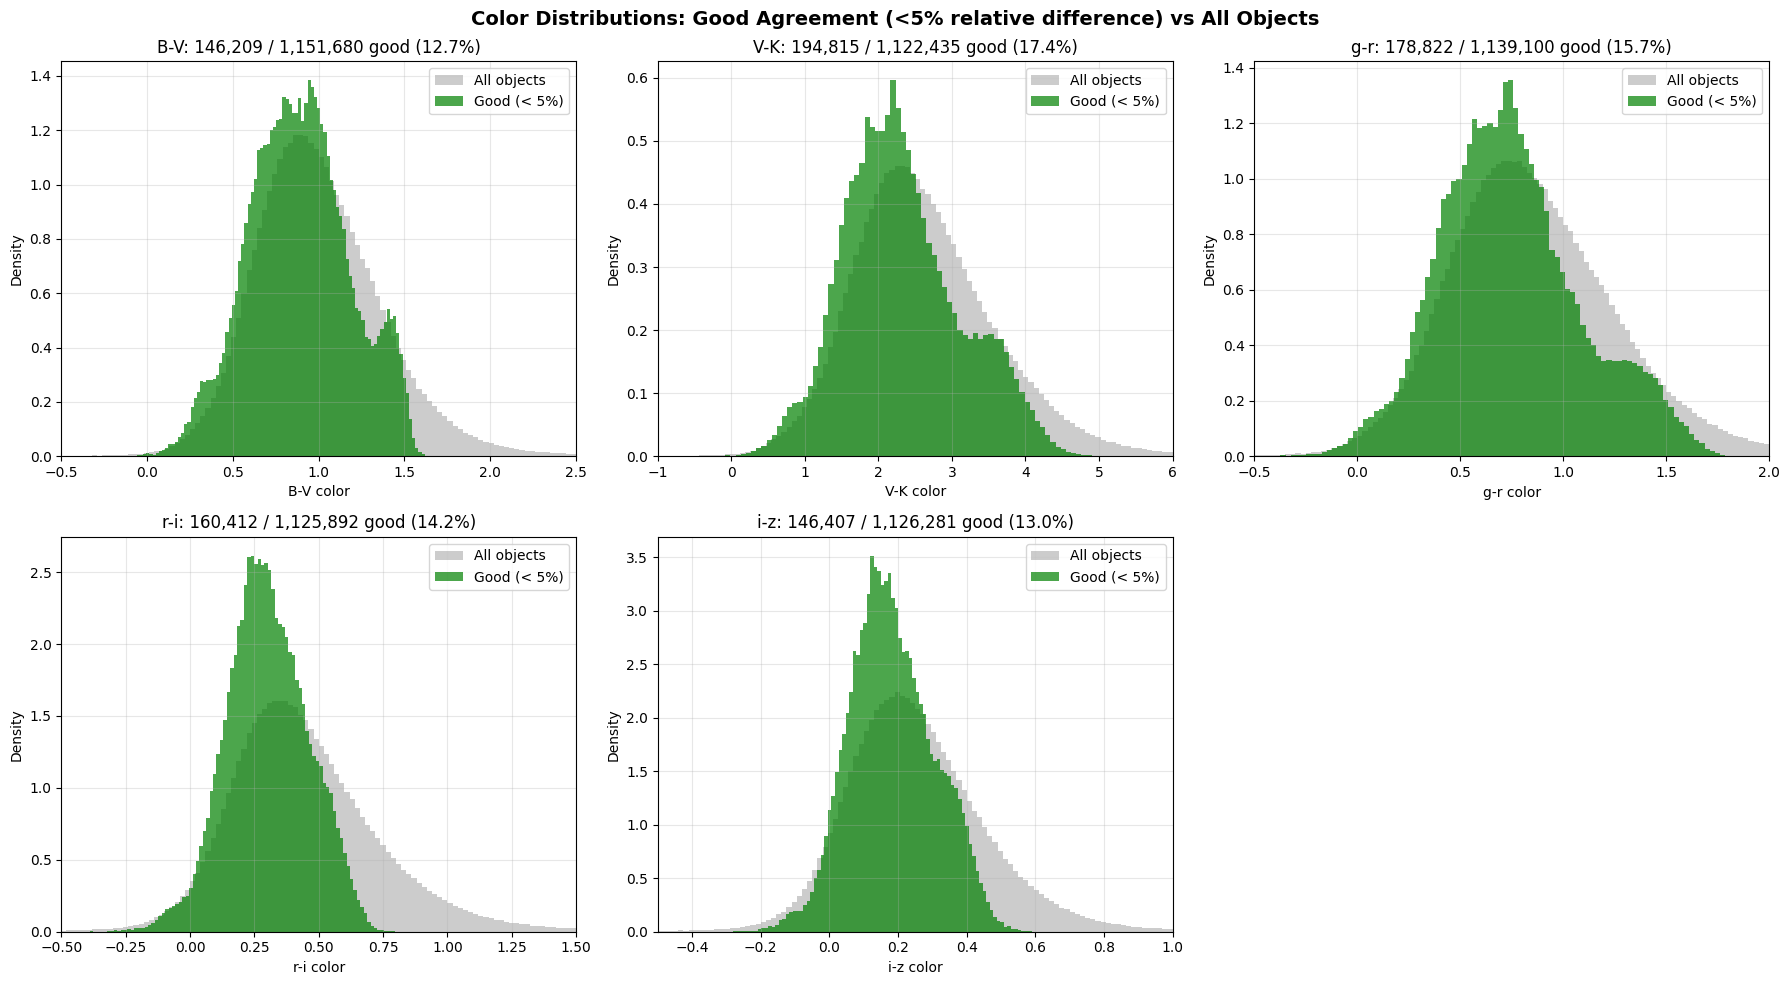


Histograms show which color ranges provide the best agreement with Gaia T_eff
Green areas indicate colors where photometric temperatures match Gaia within 5%


In [9]:
# Visualize color distributions for "good" vs "all" objects
# Using 10% threshold as the primary analysis threshold

threshold = 0.05
pct = int(threshold * 100)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

colors_to_plot = [
    ('B_V_color', 'bv', 'B-V', (-0.5, 2.5)),
    ('V_K_color', 'vk', 'V-K', (-1.0, 6.0)),
    ('g_r_color', 'gr', 'g-r', (-0.5, 2.0)),
    ('r_i_color', 'ri', 'r-i', (-0.5, 1.5)),
    ('i_z_color', 'iz', 'i-z', (-0.5, 1.0))
]

for idx, (color_col, color_name, label, xlim) in enumerate(colors_to_plot):
    ax = axes[idx]
    
    # Get data - filter to xlim range to avoid outlier skewing
    flag_col = f'{color_name}_good_{pct}pct'
    all_mask = merged[color_col].notna() & (merged[color_col] >= xlim[0]) & (merged[color_col] <= xlim[1])
    all_data = merged[all_mask][color_col]
    good_data = merged[merged[flag_col] == True][color_col]
    
    # Plot histograms with density normalization
    ax.hist(all_data, bins=100, alpha=0.4, label='All objects', color='gray', density=True)
    ax.hist(good_data, bins=100, alpha=0.7, label=f'Good (< {pct}%)', color='green', density=True)
    
    ax.set_xlabel(f'{label} color')
    ax.set_ylabel('Density')
    ax.set_title(f'{label}: {len(good_data):,} / {len(all_data):,} good ({100*len(good_data)/len(all_data):.1f}%)')
    ax.set_xlim(xlim)
    ax.legend()
    ax.grid(True, alpha=0.3)

# Remove the extra subplot
axes[5].remove()

plt.suptitle(f'Color Distributions: Good Agreement (<{pct}% relative difference) vs All Objects', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nHistograms show which color ranges provide the best agreement with Gaia T_eff")
print(f"Green areas indicate colors where photometric temperatures match Gaia within {pct}%")


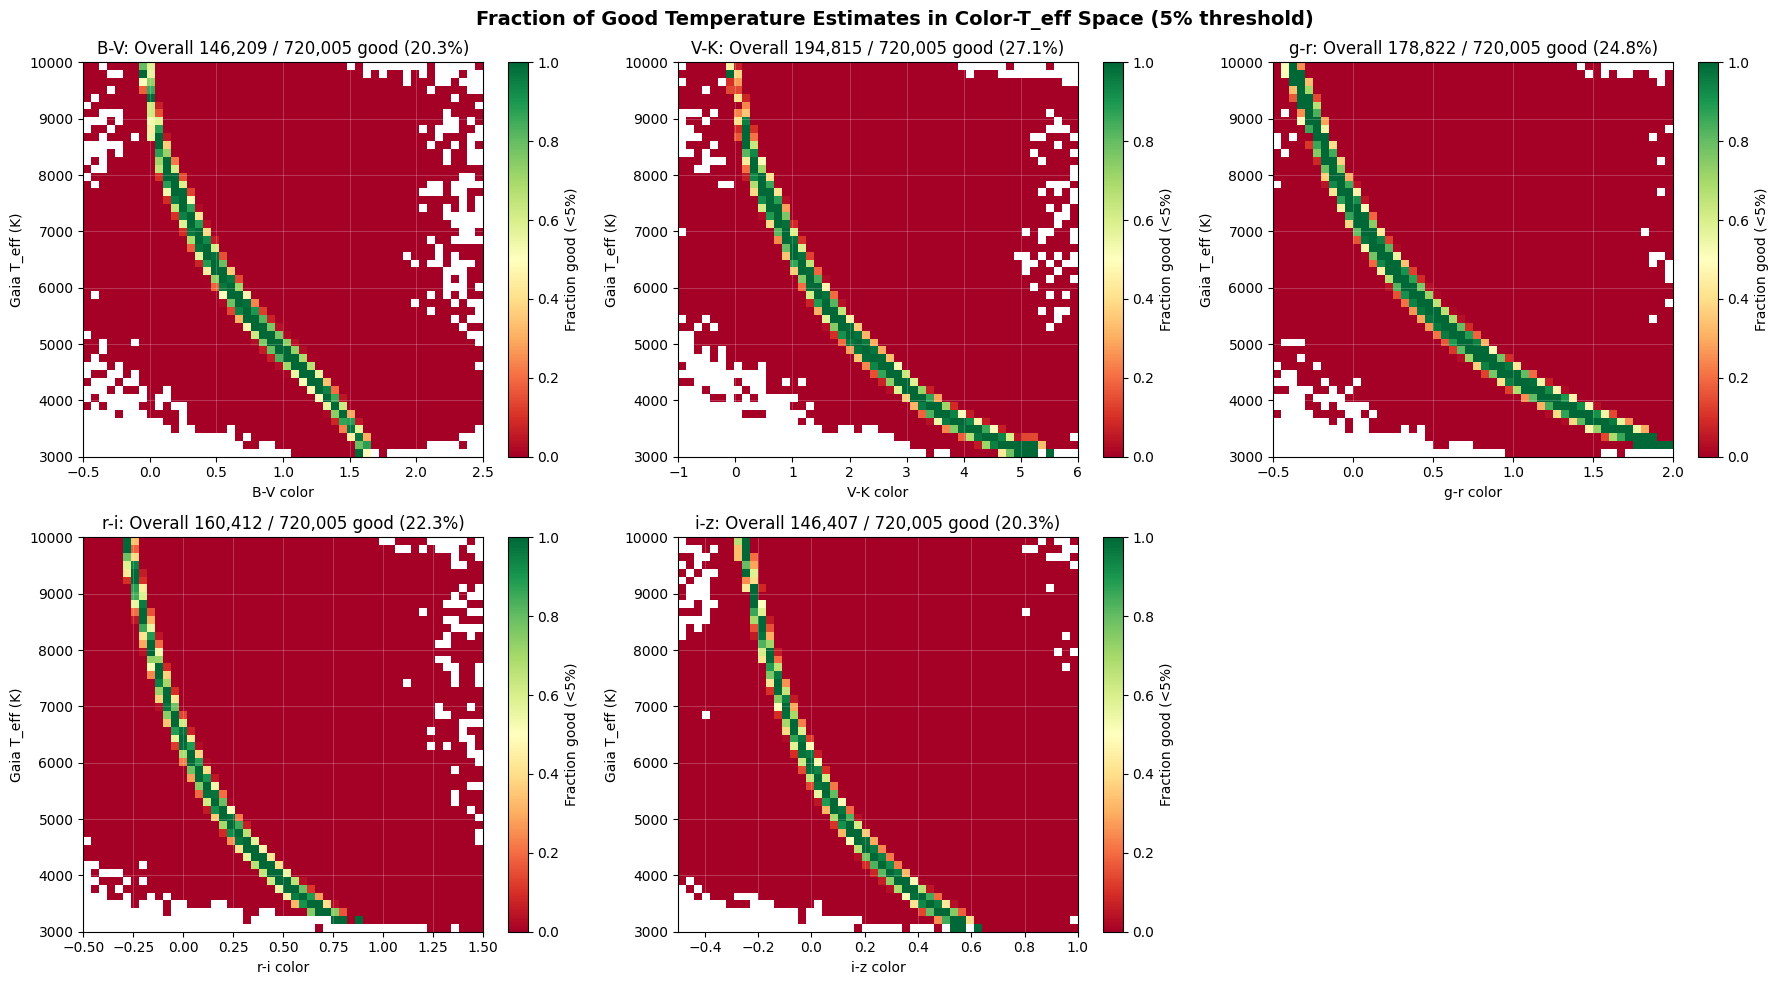


Heatmap shows fraction of objects with good agreement in each region
Green = high reliability, Red = low reliability
White regions = no data or insufficient statistics


In [10]:
# 2D Histogram: Fraction of "good" objects in Color-Temperature space
# Shows which regions have reliable temperature estimates (5% threshold)

threshold = 0.05
pct = int(threshold * 100)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

colors_to_plot = [
    ('B_V_color', 'bv', 'B-V', (-0.5, 2.5)),
    ('V_K_color', 'vk', 'V-K', (-1.0, 6.0)),
    ('g_r_color', 'gr', 'g-r', (-0.5, 2.0)),
    ('r_i_color', 'ri', 'r-i', (-0.5, 1.5)),
    ('i_z_color', 'iz', 'i-z', (-0.5, 1.0))
]

for idx, (color_col, color_name, label, xlim) in enumerate(colors_to_plot):
    ax = axes[idx]
    
    # Get data with valid Gaia T_eff
    flag_col = f'{color_name}_good_{pct}pct'
    valid_mask = (merged['teff_gspphot'] > 0) & merged[color_col].notna() & merged[flag_col].notna()
    data = merged[valid_mask]
    
    # Calculate fraction of good objects in 2D bins
    from scipy.stats import binned_statistic_2d
    
    x = data[color_col].values
    y = data['teff_gspphot'].values
    z = data[flag_col].astype(float).values  # Convert boolean to 0/1
    
    # Create 2D histogram of the fraction
    statistic, xedges, yedges, binnumber = binned_statistic_2d(
        x, y, z, statistic='mean', bins=[50, 50], 
        range=[[xlim[0], xlim[1]], [3000, 10000]]
    )
    
    # Plot as heatmap
    im = ax.imshow(statistic.T, origin='lower', aspect='auto', 
                   extent=[xlim[0], xlim[1], 3000, 10000],
                   cmap='RdYlGn', vmin=0, vmax=1)
    
    ax.set_xlabel(f'{label} color')
    ax.set_ylabel('Gaia T_eff (K)')
    ax.set_title(f'{label}: Overall {data[flag_col].sum():,} / {len(data):,} good ({100*data[flag_col].sum()/len(data):.1f}%)')
    
    # Add colorbar
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label(f'Fraction good (<{pct}%)')
    
    ax.grid(True, alpha=0.3, color='white', linewidth=0.5)

# Remove the extra subplot
axes[5].remove()

plt.suptitle(f'Fraction of Good Temperature Estimates in Color-T_eff Space ({pct}% threshold)', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nHeatmap shows fraction of objects with good agreement in each region")
print(f"Green = high reliability, Red = low reliability")
print(f"White regions = no data or insufficient statistics")


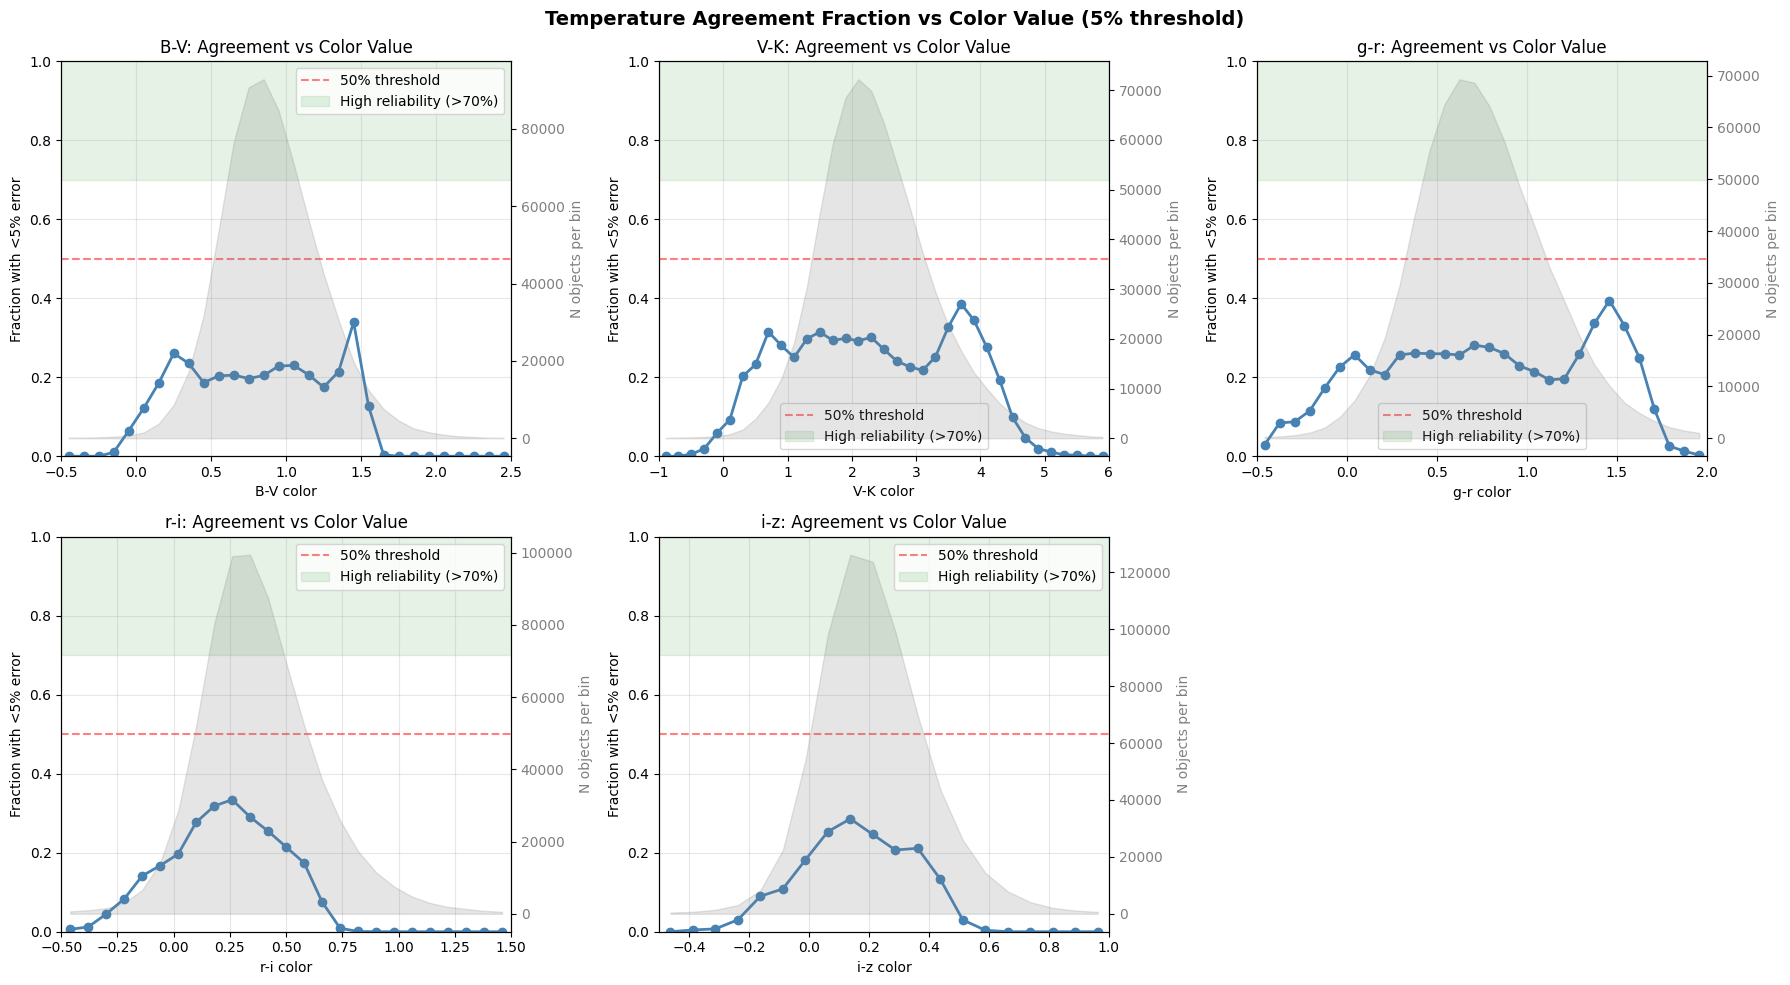


This plot shows which color ranges give reliable temperature estimates
Look for regions where the blue line is high (>0.7) with sufficient statistics (gray area)


In [11]:
# Agreement fraction vs color value (binned analysis)
# Shows which specific color ranges are most/least reliable

threshold = 0.05
pct = int(threshold * 100)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

colors_to_plot = [
    ('B_V_color', 'bv', 'B-V', (-0.5, 2.5), 30),
    ('V_K_color', 'vk', 'V-K', (-1.0, 6.0), 35),
    ('g_r_color', 'gr', 'g-r', (-0.5, 2.0), 30),
    ('r_i_color', 'ri', 'r-i', (-0.5, 1.5), 25),
    ('i_z_color', 'iz', 'i-z', (-0.5, 1.0), 20)
]

for idx, (color_col, color_name, label, xlim, n_bins) in enumerate(colors_to_plot):
    ax = axes[idx]
    
    # Get data with valid measurements
    flag_col = f'{color_name}_good_{pct}pct'
    valid_mask = (merged['teff_gspphot'] > 0) & merged[color_col].notna() & merged[flag_col].notna()
    data = merged[valid_mask]
    
    # Filter to xlim range
    in_range = (data[color_col] >= xlim[0]) & (data[color_col] <= xlim[1])
    data = data[in_range]
    
    # Create bins
    bins = np.linspace(xlim[0], xlim[1], n_bins + 1)
    bin_centers = (bins[:-1] + bins[1:]) / 2
    
    # Calculate fraction of good objects in each bin
    fractions = []
    counts = []
    
    for i in range(len(bins) - 1):
        bin_mask = (data[color_col] >= bins[i]) & (data[color_col] < bins[i+1])
        bin_data = data[bin_mask]
        
        if len(bin_data) > 0:
            fraction_good = bin_data[flag_col].sum() / len(bin_data)
            fractions.append(fraction_good)
            counts.append(len(bin_data))
        else:
            fractions.append(np.nan)
            counts.append(0)
    
    # Plot fraction vs color
    ax.plot(bin_centers, fractions, 'o-', linewidth=2, markersize=6, color='steelblue')
    ax.axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='50% threshold')
    
    # Add shaded region for "good" performance
    ax.axhspan(0.7, 1.0, alpha=0.1, color='green', label='High reliability (>70%)')
    
    ax.set_xlabel(f'{label} color')
    ax.set_ylabel(f'Fraction with <{pct}% error')
    ax.set_title(f'{label}: Agreement vs Color Value')
    ax.set_xlim(xlim)
    ax.set_ylim(0, 1)
    ax.legend(loc='best')
    ax.grid(True, alpha=0.3)
    
    # Add secondary y-axis for counts
    ax2 = ax.twinx()
    ax2.fill_between(bin_centers, counts, alpha=0.2, color='gray', label='Object count')
    ax2.set_ylabel('N objects per bin', color='gray')
    ax2.tick_params(axis='y', labelcolor='gray')

# Remove the extra subplot
axes[5].remove()

plt.suptitle(f'Temperature Agreement Fraction vs Color Value ({pct}% threshold)', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nThis plot shows which color ranges give reliable temperature estimates")
print(f"Look for regions where the blue line is high (>0.7) with sufficient statistics (gray area)")


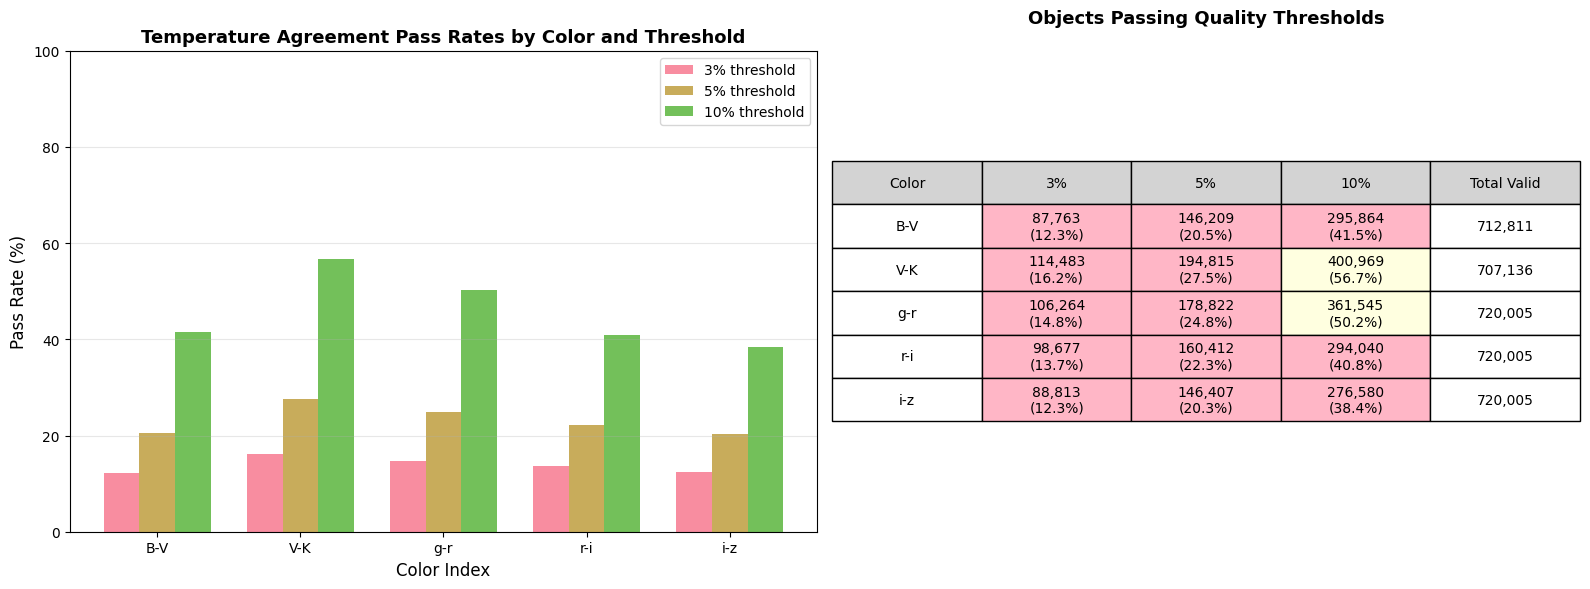


SUMMARY AND RECOMMENDATIONS

Best performing colors (at 5% threshold):
  B-V : 20.51% pass rate (146,209 / 712,811 objects)
  V-K : 27.55% pass rate (194,815 / 707,136 objects)
  g-r : 24.84% pass rate (178,822 / 720,005 objects)
  r-i : 22.28% pass rate (160,412 / 720,005 objects)
  i-z : 20.33% pass rate (146,407 / 720,005 objects)

Color coding: Green ≥70%, Yellow ≥50%, Red <50%


In [12]:
# Summary comparison: Overall pass rates for all colors at all thresholds

thresholds = [0.03, 0.05, 0.10]
color_names = ['bv', 'vk', 'gr', 'ri', 'iz']
color_labels = ['B-V', 'V-K', 'g-r', 'r-i', 'i-z']

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# --- Left plot: Bar chart comparison ---
x = np.arange(len(color_labels))
width = 0.25

for i, threshold in enumerate(thresholds):
    pct = int(threshold * 100)
    pass_rates = []
    
    for color in color_names:
        flag_col = f'{color}_good_{pct}pct'
        resid_col = f'rel_resid_{color}'
        
        n_valid = merged[resid_col].notna().sum()
        n_pass = merged[flag_col].sum()
        
        if n_valid > 0:
            pass_rate = 100 * n_pass / n_valid
        else:
            pass_rate = 0
        
        pass_rates.append(pass_rate)
    
    ax1.bar(x + i*width, pass_rates, width, label=f'{pct}% threshold', alpha=0.8)

ax1.set_xlabel('Color Index', fontsize=12)
ax1.set_ylabel('Pass Rate (%)', fontsize=12)
ax1.set_title('Temperature Agreement Pass Rates by Color and Threshold', fontsize=13, fontweight='bold')
ax1.set_xticks(x + width)
ax1.set_xticklabels(color_labels)
ax1.legend()
ax1.grid(True, alpha=0.3, axis='y')
ax1.set_ylim(0, 100)

# --- Right plot: Summary table ---
# Create summary statistics table
summary_data = []

for color, label in zip(color_names, color_labels):
    row = [label]
    
    for threshold in thresholds:
        pct = int(threshold * 100)
        flag_col = f'{color}_good_{pct}pct'
        resid_col = f'rel_resid_{color}'
        
        n_valid = merged[resid_col].notna().sum()
        n_pass = merged[flag_col].sum()
        
        if n_valid > 0:
            pass_rate = 100 * n_pass / n_valid
            row.append(f'{n_pass:,}\n({pass_rate:.1f}%)')
        else:
            row.append('N/A')
    
    # Add total valid count
    n_valid = merged[resid_col].notna().sum()
    row.append(f'{n_valid:,}')
    
    summary_data.append(row)

# Create table
columns = ['Color'] + [f'{int(t*100)}%' for t in thresholds] + ['Total Valid']
ax2.axis('tight')
ax2.axis('off')

table = ax2.table(cellText=summary_data, colLabels=columns,
                  cellLoc='center', loc='center',
                  colColours=['lightgray']*len(columns))

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2.5)

# Color-code the pass rate columns
for i in range(1, len(summary_data) + 1):
    for j in range(1, 4):  # Threshold columns
        cell_text = summary_data[i-1][j]
        if cell_text != 'N/A':
            pct_value = float(cell_text.split('(')[1].split('%')[0])
            if pct_value >= 70:
                table[(i, j)].set_facecolor('#90EE90')  # Light green
            elif pct_value >= 50:
                table[(i, j)].set_facecolor('#FFFFE0')  # Light yellow
            else:
                table[(i, j)].set_facecolor('#FFB6C6')  # Light red

ax2.set_title('Objects Passing Quality Thresholds', fontsize=13, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

# Print recommendations
print("\n" + "="*70)
print("SUMMARY AND RECOMMENDATIONS")
print("="*70)

print("\nBest performing colors (at 5% threshold):")
for color, label in zip(color_names, color_labels):
    flag_col = f'{color}_good_5pct'
    resid_col = f'rel_resid_{color}'
    n_valid = merged[resid_col].notna().sum()
    n_pass = merged[flag_col].sum()
    if n_valid > 0:
        pass_rate = 100 * n_pass / n_valid
        print(f"  {label:4s}: {pass_rate:5.2f}% pass rate ({n_pass:,} / {n_valid:,} objects)")

print("\nColor coding: Green ≥70%, Yellow ≥50%, Red <50%")


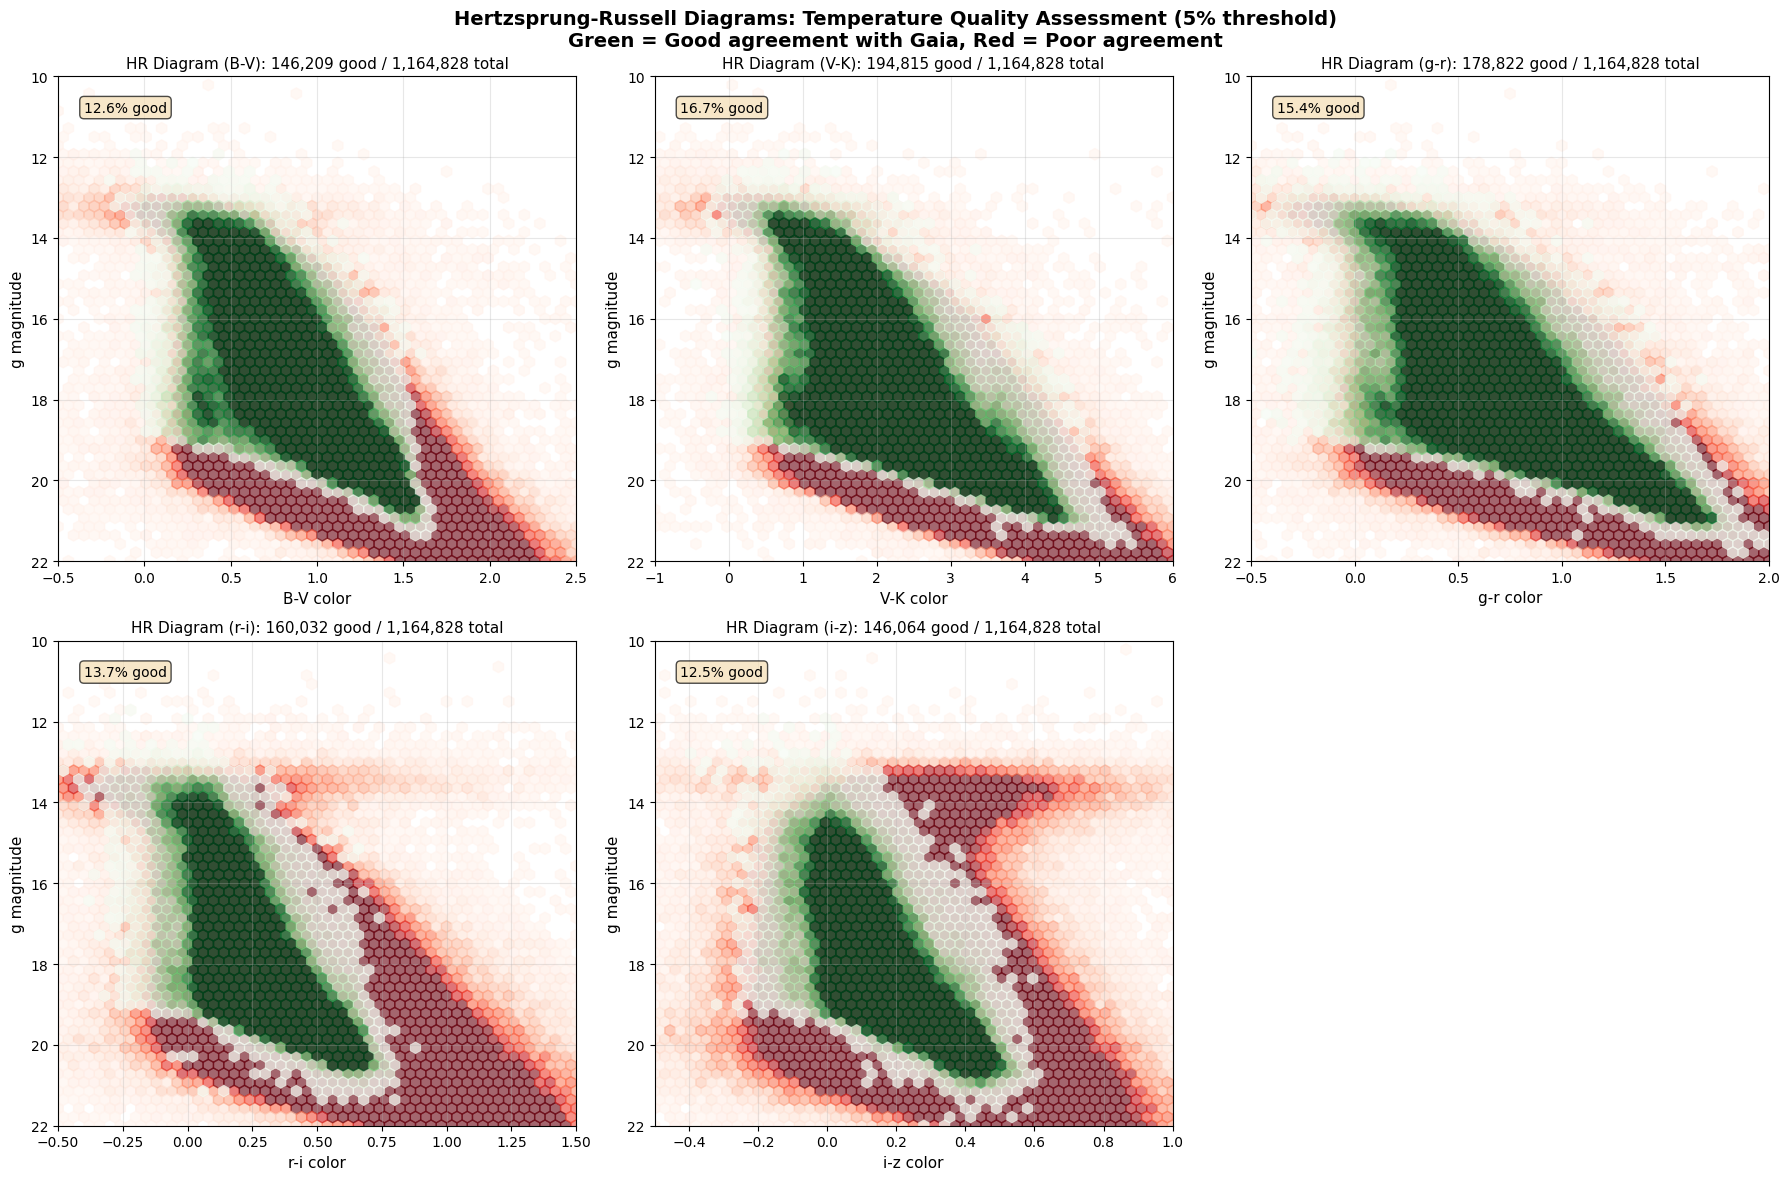


HR diagrams show the distribution of good (green) vs bad (red) temperature estimates
Look for systematic patterns - are certain regions of the HR diagram more reliable?


In [13]:
# Hertzsprung-Russell diagrams: g magnitude vs color
# Shows where "good" temperature estimates are located in the HR diagram

threshold = 0.05
pct = int(threshold * 100)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

colors_to_plot = [
    ('B_V_color', 'bv', 'B-V', (-0.5, 2.5)),
    ('V_K_color', 'vk', 'V-K', (-1.0, 6.0)),
    ('g_r_color', 'gr', 'g-r', (-0.5, 2.0)),
    ('r_i_color', 'ri', 'r-i', (-0.5, 1.5)),
    ('i_z_color', 'iz', 'i-z', (-0.5, 1.0))
]

for idx, (color_col, color_name, label, xlim) in enumerate(colors_to_plot):
    ax = axes[idx]
    
    # Get data with valid measurements
    flag_col = f'{color_name}_good_{pct}pct'
    valid_mask = (merged['gPSFMag'].notna() & 
                   merged[color_col].notna() & 
                   merged[flag_col].notna() &
                   (merged['gPSFMag'] > 0) &
                   (merged['gPSFMag'] < 25))  # Reasonable magnitude limit
    data = merged[valid_mask]
    
    # Separate good and bad objects
    good_mask = data[flag_col] == True
    bad_mask = data[flag_col] == False
    
    # Create 2D histogram for all objects (background)
    from scipy.stats import binned_statistic_2d
    
    # Plot bad objects as red points (background)
    if bad_mask.sum() > 0:
        ax.hexbin(data[bad_mask][color_col], data[bad_mask]['gPSFMag'],
                  gridsize=50, cmap='Reds', mincnt=1, alpha=0.6, 
                  extent=[xlim[0], xlim[1], 10, 22], vmin=0, vmax=100)
    
    # Overlay good objects in green
    if good_mask.sum() > 0:
        ax.hexbin(data[good_mask][color_col], data[good_mask]['gPSFMag'],
                  gridsize=50, cmap='Greens', mincnt=1, alpha=0.7,
                  extent=[xlim[0], xlim[1], 10, 22], vmin=0, vmax=100)
    
    ax.set_xlabel(f'{label} color', fontsize=11)
    ax.set_ylabel('g magnitude', fontsize=11)
    ax.set_title(f'HR Diagram ({label}): {good_mask.sum():,} good / {len(data):,} total', fontsize=11)
    ax.set_xlim(xlim)
    ax.set_ylim(22, 10)  # Inverted for magnitudes (brighter at top)
    ax.grid(True, alpha=0.3)
    
    # Add text showing percentage
    pct_good = 100 * good_mask.sum() / len(data) if len(data) > 0 else 0
    ax.text(0.05, 0.95, f'{pct_good:.1f}% good', 
            transform=ax.transAxes, fontsize=10,
            verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))

# Remove the extra subplot
axes[5].remove()

plt.suptitle(f'Hertzsprung-Russell Diagrams: Temperature Quality Assessment ({pct}% threshold)\n' +
             'Green = Good agreement with Gaia, Red = Poor agreement', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nHR diagrams show the distribution of good (green) vs bad (red) temperature estimates")
print(f"Look for systematic patterns - are certain regions of the HR diagram more reliable?")


In [14]:
# Save the updated table with quality flags back to parquet file

# Select columns to save (original columns + new ones)
# Get list of new columns we added
new_columns = []

# Relative residual columns
new_columns.extend(['rel_resid_bv', 'rel_resid_vk', 'rel_resid_gr', 'rel_resid_ri', 'rel_resid_iz'])

# Quality flag columns
flag_columns = [col for col in merged.columns if '_good_' in col and 'pct' in col]
new_columns.extend(flag_columns)

print(f"Columns to add to the dataset:")
print(f"  Relative residuals: 5 columns")
print(f"  Quality flags: {len(flag_columns)} columns")
print(f"  Total new columns: {len(new_columns)}")

# Extract only the Pan-STARRS + temperature data with new flags
# This corresponds to the original panstarrs_temp structure plus new columns
cols_to_save = list(panstarrs_temp.columns) + new_columns

# Get the data for objects that were in the original panstarrs_temp
# Match by original_ext_source_id
output_data = merged[merged['original_ext_source_id'].isin(panstarrs_temp['original_ext_source_id'])][cols_to_save]

print(f"\nOriginal Pan-STARRS data: {panstarrs_temp.shape}")
print(f"Updated data with flags: {output_data.shape}")

# Save to new file
output_file = data_dir / 'gaia_eb_panstarrs_phot_with_temperatures_and_flags.parquet'
print(f"\nSaving to: {output_file}")

output_data.to_parquet(output_file, index=False)

print(f"✓ Saved successfully!")
print(f"\nFile contains:")
print(f"  - Original photometry and temperature columns")
print(f"  - Relative residuals for all 5 color-temperature relations")
print(f"  - Quality flags at 3%, 5%, and 10% thresholds")
print(f"  - Total: {output_data.shape[1]} columns, {output_data.shape[0]:,} rows")

# Display summary of flag columns
print(f"\nQuality flag columns added:")
for col in sorted(flag_columns):
    n_good = output_data[col].sum()
    n_total = output_data[col].notna().sum()
    pct = 100 * n_good / n_total if n_total > 0 else 0
    print(f"  {col:20s}: {n_good:7,} / {n_total:7,} ({pct:5.1f}%)")


Columns to add to the dataset:
  Relative residuals: 5 columns
  Quality flags: 15 columns
  Total new columns: 20

Original Pan-STARRS data: (1172535, 29)
Updated data with flags: (1172580, 49)

Saving to: ../data/processed/gaia_eb_panstarrs_phot_with_temperatures_and_flags.parquet
✓ Saved successfully!

File contains:
  - Original photometry and temperature columns
  - Relative residuals for all 5 color-temperature relations
  - Quality flags at 3%, 5%, and 10% thresholds
  - Total: 49 columns, 1,172,580 rows

Quality flag columns added:
  bv_good_10pct       : 295,864 / 1,172,580 ( 25.2%)
  bv_good_3pct        :  87,763 / 1,172,580 (  7.5%)
  bv_good_5pct        : 146,209 / 1,172,580 ( 12.5%)
  gr_good_10pct       : 361,545 / 1,172,580 ( 30.8%)
  gr_good_3pct        : 106,264 / 1,172,580 (  9.1%)
  gr_good_5pct        : 178,822 / 1,172,580 ( 15.3%)
  iz_good_10pct       : 276,580 / 1,172,580 ( 23.6%)
  iz_good_3pct        :  88,813 / 1,172,580 (  7.6%)
  iz_good_5pct        : 146,40